# DIABETES PREDICTION PROJECT

### DATA CLEANING

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from plotnine import *
import janitor

In [2]:
# Load dataset

diabetes_data= pd.read_csv('diabetes_prediction_dataset.csv')

In [3]:
diabetes_data.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [4]:
# Check for nulls

diabetes_data.isna().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [5]:
# Check for duplicates

diabetes_data.duplicated().sum()

np.int64(3854)

In [6]:
# Check num of rows & cols 

diabetes_data.shape

(100000, 9)

In [7]:
# Check data description

diabetes_data.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


##### Interpretation


1. Patients in the highest 25% have blood glucose levels above 159 mg/dL, which could suggest an increased risk of diabetes.

2. Blood glucose levels show a wide spread, ranging from 80 to 300 mg/dL, indicating strong variation among patients.

3. The average blood glucose level is 138.2 mg/dL, while the median is 140 mg/dL, showing a fairly balanced distribution.

4. About 4.1% of patients have heart disease, while the vast majority (95.9%) do not.

5. Hypertension is also uncommon, affecting roughly 7.8% of patients, with 92.2% being free of it.

6. The average HbA1c level is 5.53, which is generally considered normal. However, up to the 75th percentile, values reach 6.2, which is already in the prediabetes range.

7. Around 8.8% of patients have diabetes, while the remaining 91.2% do not.

8. BMI values show noticeable extremes, with a very low minimum of 10.01 and a very high maximum of 95.69, suggesting outliers are present.

9. Most patients (75%) have a BMI of 29.86 or lower.

10. The average BMI is 27.32, and since the mean and median are close, the distribution appears fairly normal.

11. Age distribution shows that 75% of patients are 59 years old or below.

12. The youngest patient is about 0.08 years old (roughly a newborn), while the oldest is 80 years old.

In [8]:
# Check info of the dataset

diabetes_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  str    
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  str    
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 8.0 MB


In [9]:
# Drop duplicates

cleaned_data = diabetes_data.drop_duplicates()

In [10]:
# Create a copy

cleaned_data_cpy = diabetes_data.drop_duplicates()

In [11]:
# Check num of rows & cols of cleaned data

cleaned_data.shape

(96146, 9)

In [12]:
# Check num or duplicates


cleaned_data.duplicated().sum()

np.int64(0)

In [13]:
# Check for skewness

cleaned_data.select_dtypes(include = 'number').skew()

age                   -0.062445
hypertension           3.157676
heart_disease          4.642359
bmi                    1.023751
HbA1c_level           -0.054463
blood_glucose_level    0.836489
diabetes               2.903845
dtype: float64

### EXPLORATORY DATA ANALYSIS

#### What is the distribution of diabetes diagnosis among patients? Percentage of diabetic & non-diabetic patients


In [14]:

cleaned_data['diabetes'].value_counts(normalize = True) * 100

diabetes
0    91.178
1     8.822
Name: proportion, dtype: float64

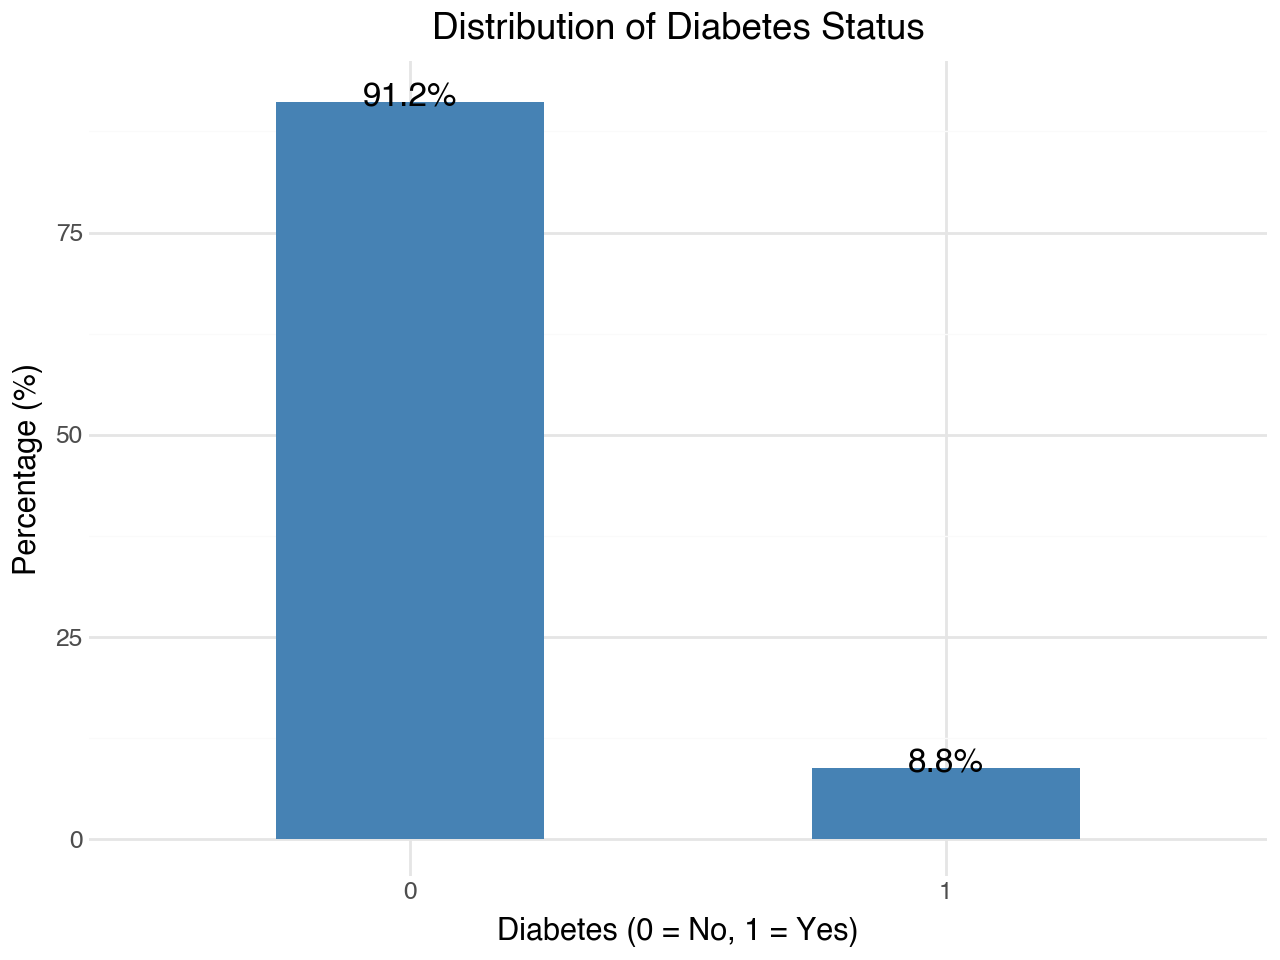

In [15]:
# Diabetes patients distribution


# Calculate percentages first
diabetes_pct = cleaned_data['diabetes'].value_counts(normalize=True).reset_index()
diabetes_pct.columns = ['diabetes', 'percentage']
diabetes_pct['percentage'] = diabetes_pct['percentage'] * 100
diabetes_pct['label'] = diabetes_pct['percentage'].round(1).astype(str) + '%'

(
    ggplot(diabetes_pct, aes(x='factor(diabetes)', y='percentage'))
    + geom_bar(stat='identity', fill='steelblue', width= 0.5)
    + geom_text(aes(label='label'), nudge_y=0.5, size=12)
    + theme_minimal()
    + labs(
        title='Distribution of Diabetes Status',
        x='Diabetes (0 = No, 1 = Yes)',
        y='Percentage (%)'
    )
)

##### Interpretation

The distribution of non_diabetic patients is more with 91.78% ie 91.2% approx and diabeteics 8.22%

#### What is the gender distribution of patients. What is the the prevalence of diabetes among both gender?

In [16]:
cleaned_data['gender'].value_counts()

gender
Female    56161
Male      39967
Other        18
Name: count, dtype: int64

In [17]:
cleaned_data.groupby('diabetes')['gender'].value_counts()

diabetes  gender
0         Female    51714
          Male      35932
          Other        18
1         Female     4447
          Male       4035
Name: count, dtype: int64

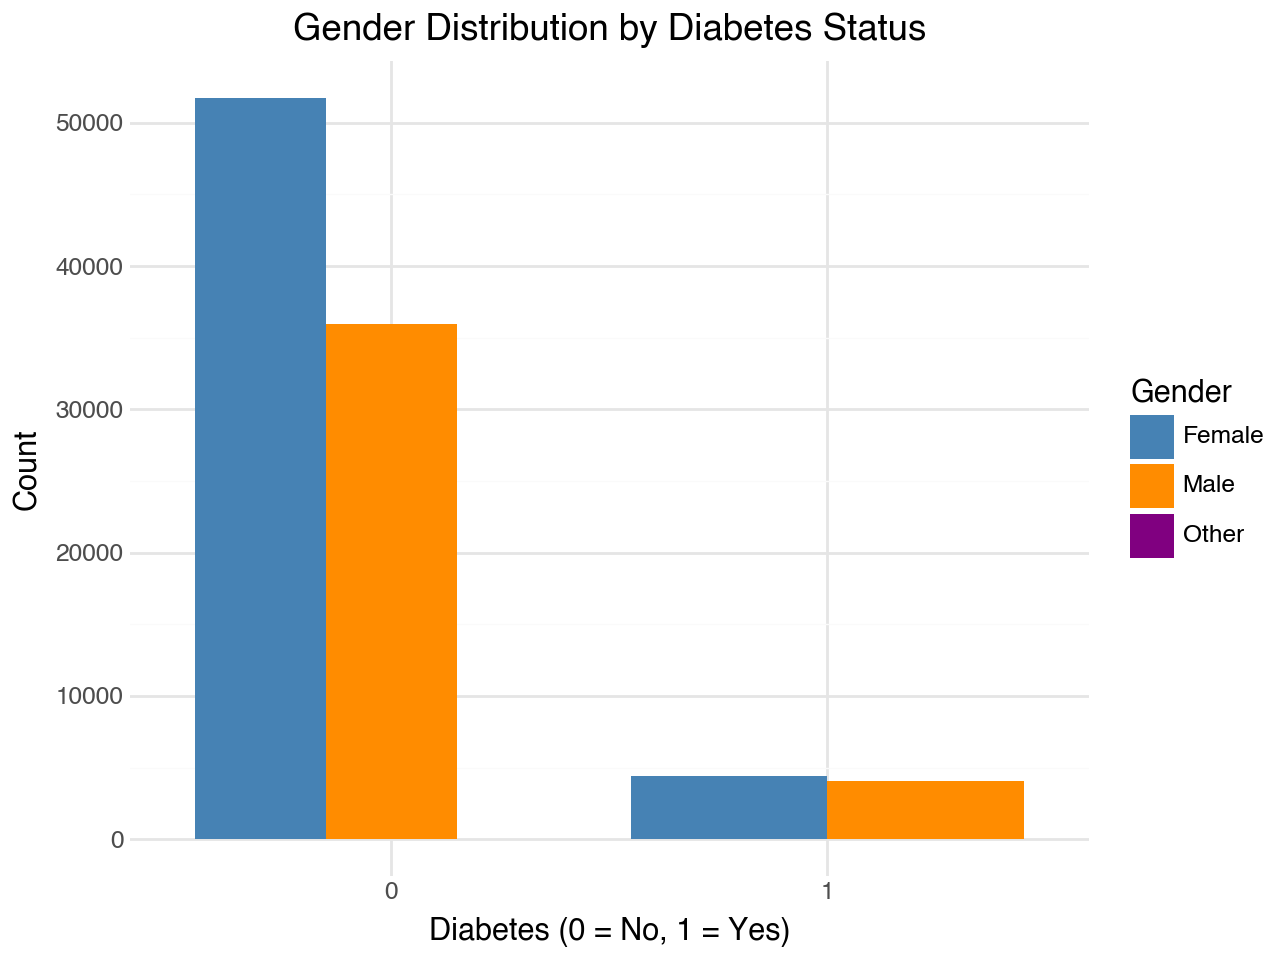

In [18]:
(
    ggplot(cleaned_data, aes(x='factor(diabetes)', fill='gender'))
    + geom_bar(position='dodge')
    + scale_fill_manual(values=['steelblue', 'darkorange', 'purple'])
    + theme_minimal()
    + labs(
        title='Gender Distribution by Diabetes Status',
        x='Diabetes (0 = No, 1 = Yes)',
        y='Count',
        fill='Gender'
    )
)

##### Interpretation
The dataset contains 56,161 females, 39,967 males, and 18 individuals classified as “other”, indicating a female-dominated sample.
Among non-diabetic patients, females account for 51,714 cases compared to 35,932 males. Among diabetic patients, females also slightly outnumber males with 4,447 cases versus 4,035.
Overall, females are more represented in both diabetic and non-diabetic groups, though the difference between genders among diabetic cases is relatively small.
    

#### Is age correlated with diabetes?


In [19]:

cleaned_data.groupby('diabetes')['age'].mean()

diabetes
0    39.943229
1    60.925961
Name: age, dtype: float64

In [20]:

cleaned_data['diabetes'].corr(cleaned_data['age'])

np.float64(0.26492692423606934)

##### Interpretation
Age has a weak positive correlation with diabetes (r = 0.26). This means as age increases, the likelihood of diabetes increases slightly; older patients tend to have higher diabetes rates, but age alone is not a strong predictor. This is consistent with what your correlation matrix showed earlier.

#### Which age group has the most diabetes?


In [21]:

cleaned_data['age_group'] = pd.cut(
    cleaned_data['age'],
    bins = [0, 30, 40, 50, 60, 70, 80],
    labels = [ '0-30', '31-40', '41-50', '51-60', '61-70', '71-80'] 
)


In [22]:
cleaned_data.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes,age_group
0,Female,80.0,0,1,never,25.19,6.6,140,0,71-80
1,Female,54.0,0,0,No Info,27.32,6.6,80,0,51-60
2,Male,28.0,0,0,never,27.32,5.7,158,0,0-30
3,Female,36.0,0,0,current,23.45,5.0,155,0,31-40
4,Male,76.0,1,1,current,20.14,4.8,155,0,71-80


In [23]:

cleaned_data.groupby('age_group')['diabetes'].sum()

age_group
0-30      301
31-40     479
41-50    1068
51-60    1928
61-70    2228
71-80    2478
Name: diabetes, dtype: int64

In [24]:
cleaned_data.groupby('age_group')['diabetes'].mean() * 100

age_group
0-30      0.928497
31-40     3.793759
41-50     7.567491
51-60    13.403782
61-70    20.166546
71-80    21.441551
Name: diabetes, dtype: float64

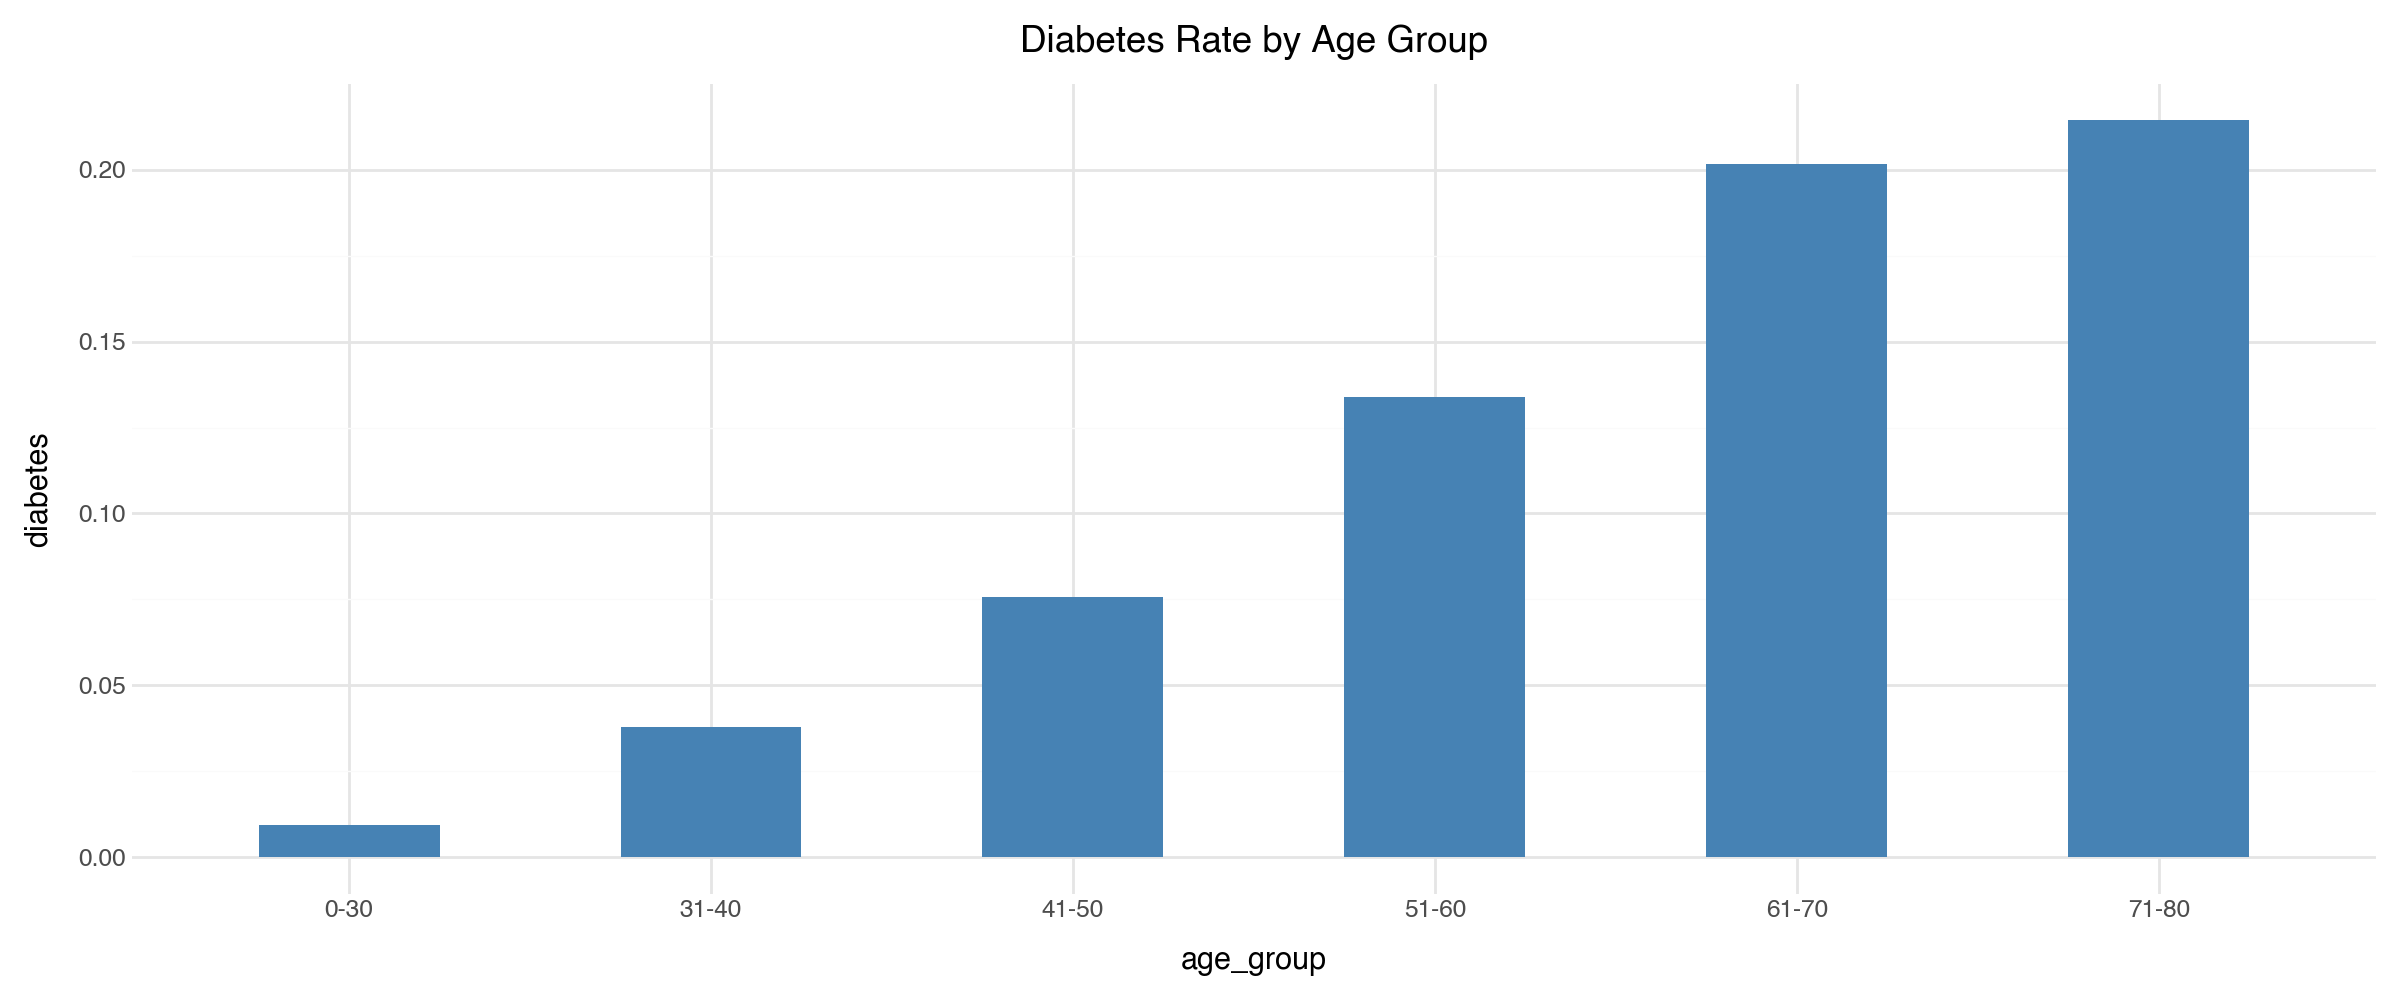

In [25]:
age_rate = cleaned_data.groupby('age_group', as_index = False)['diabetes'].mean()

(
    ggplot(age_rate, aes(x = 'age_group', y='diabetes'))
    + geom_bar(stat = 'identity', fill = 'steelblue', width =0.5)
    + theme_minimal()
    + theme(figure_size=(12, 5))
    + labs(
        title = 'Diabetes Rate by Age Group',
        x = 'age_group',
        y = 'diabetes'
    )  
    
)

##### Interpretation
The 71–80 age group has the highest diabetes prevalence, with approximately 21.44% of individuals in that age range 
diagnosed with diabetes.

#### Is hypertension associated with a diabetes diagnosis? Do patients with hypertension have higher diabetes rates?


In [26]:

hypertension_data = cleaned_data.groupby('diabetes', as_index=False)['hypertension'].mean()
hypertension_data['hypertension'] = hypertension_data['hypertension'] * 100

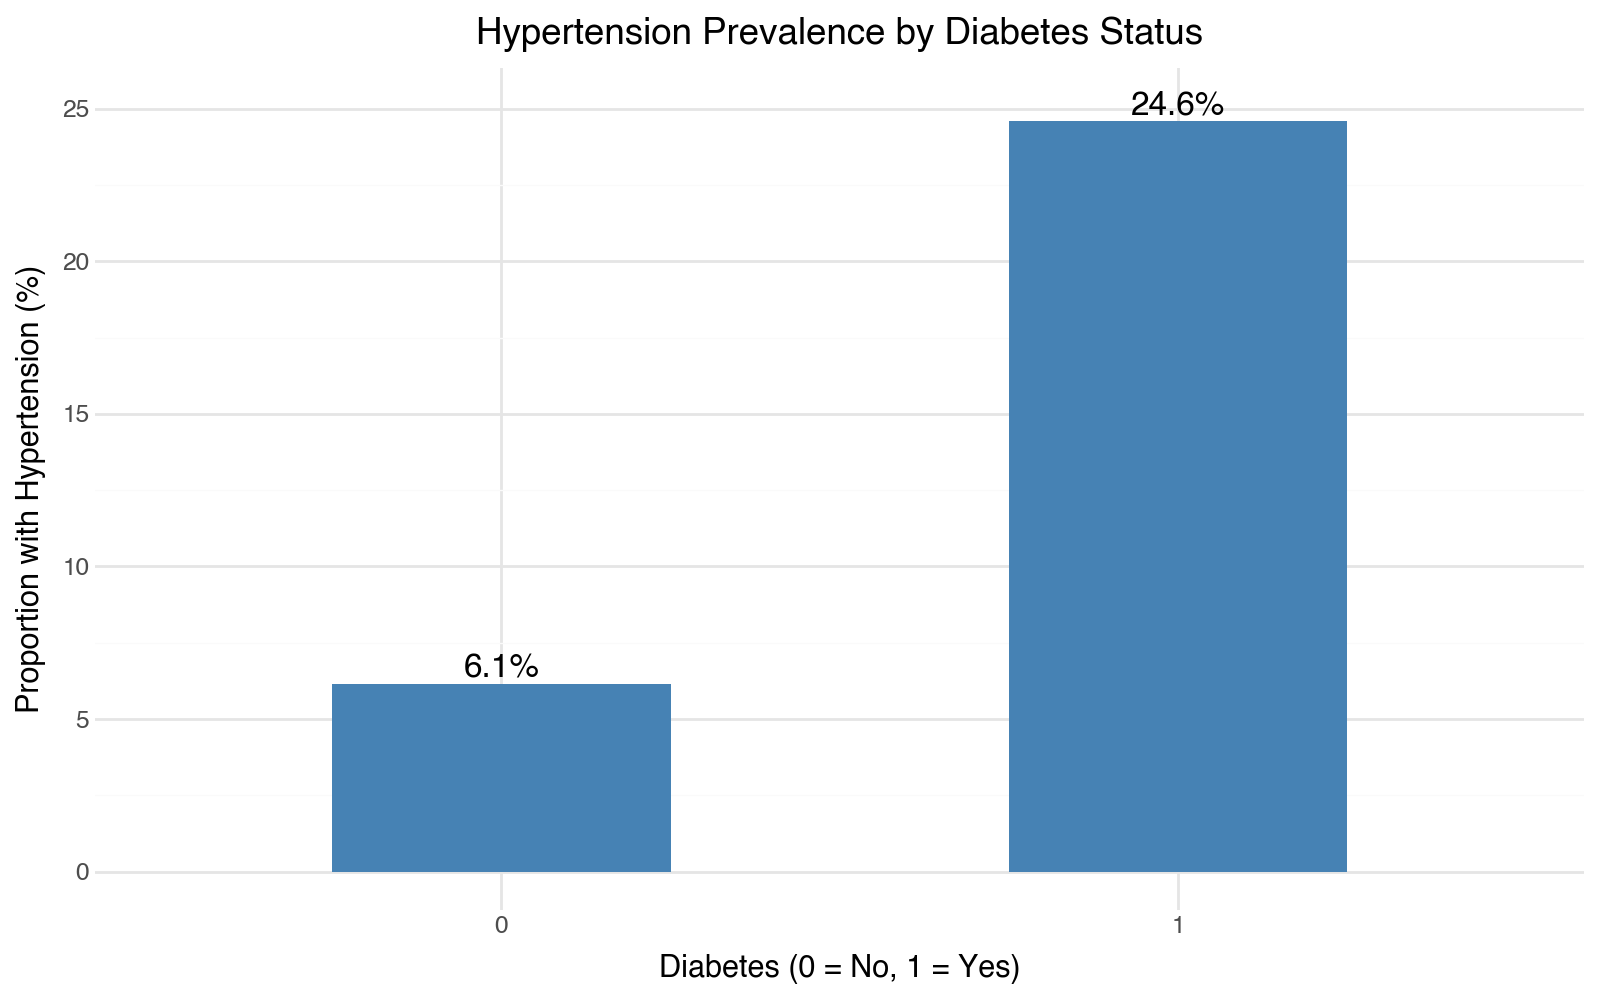

In [27]:


hypertension_data['label'] = hypertension_data['hypertension'].round(1).astype(str) + '%'

(
    ggplot(hypertension_data, aes(x='factor(diabetes)', y='hypertension'))
    + geom_bar(stat='identity', fill='steelblue', width=0.5)
    + geom_text(aes(label='label'), nudge_y=0.5, size=12)
    + labs(
        title='Hypertension Prevalence by Diabetes Status',
        x='Diabetes (0 = No, 1 = Yes)',
        y='Proportion with Hypertension (%)'
    )
    + theme_minimal()
    + theme(figure_size=(8, 5))
)

##### Interpretation
Patients diagnosed with diabetes show a higher proportion of hypertension compared to non-diabetic patients, suggesting 
a positive association between both conditions.

#### Is heart disease associated with diabetes diagnosis?

In [28]:

heartdx_data = cleaned_data.groupby('diabetes', as_index=False)['heart_disease'].mean()
heartdx_data['heart_disease'] = heartdx_data['heart_disease'] * 100

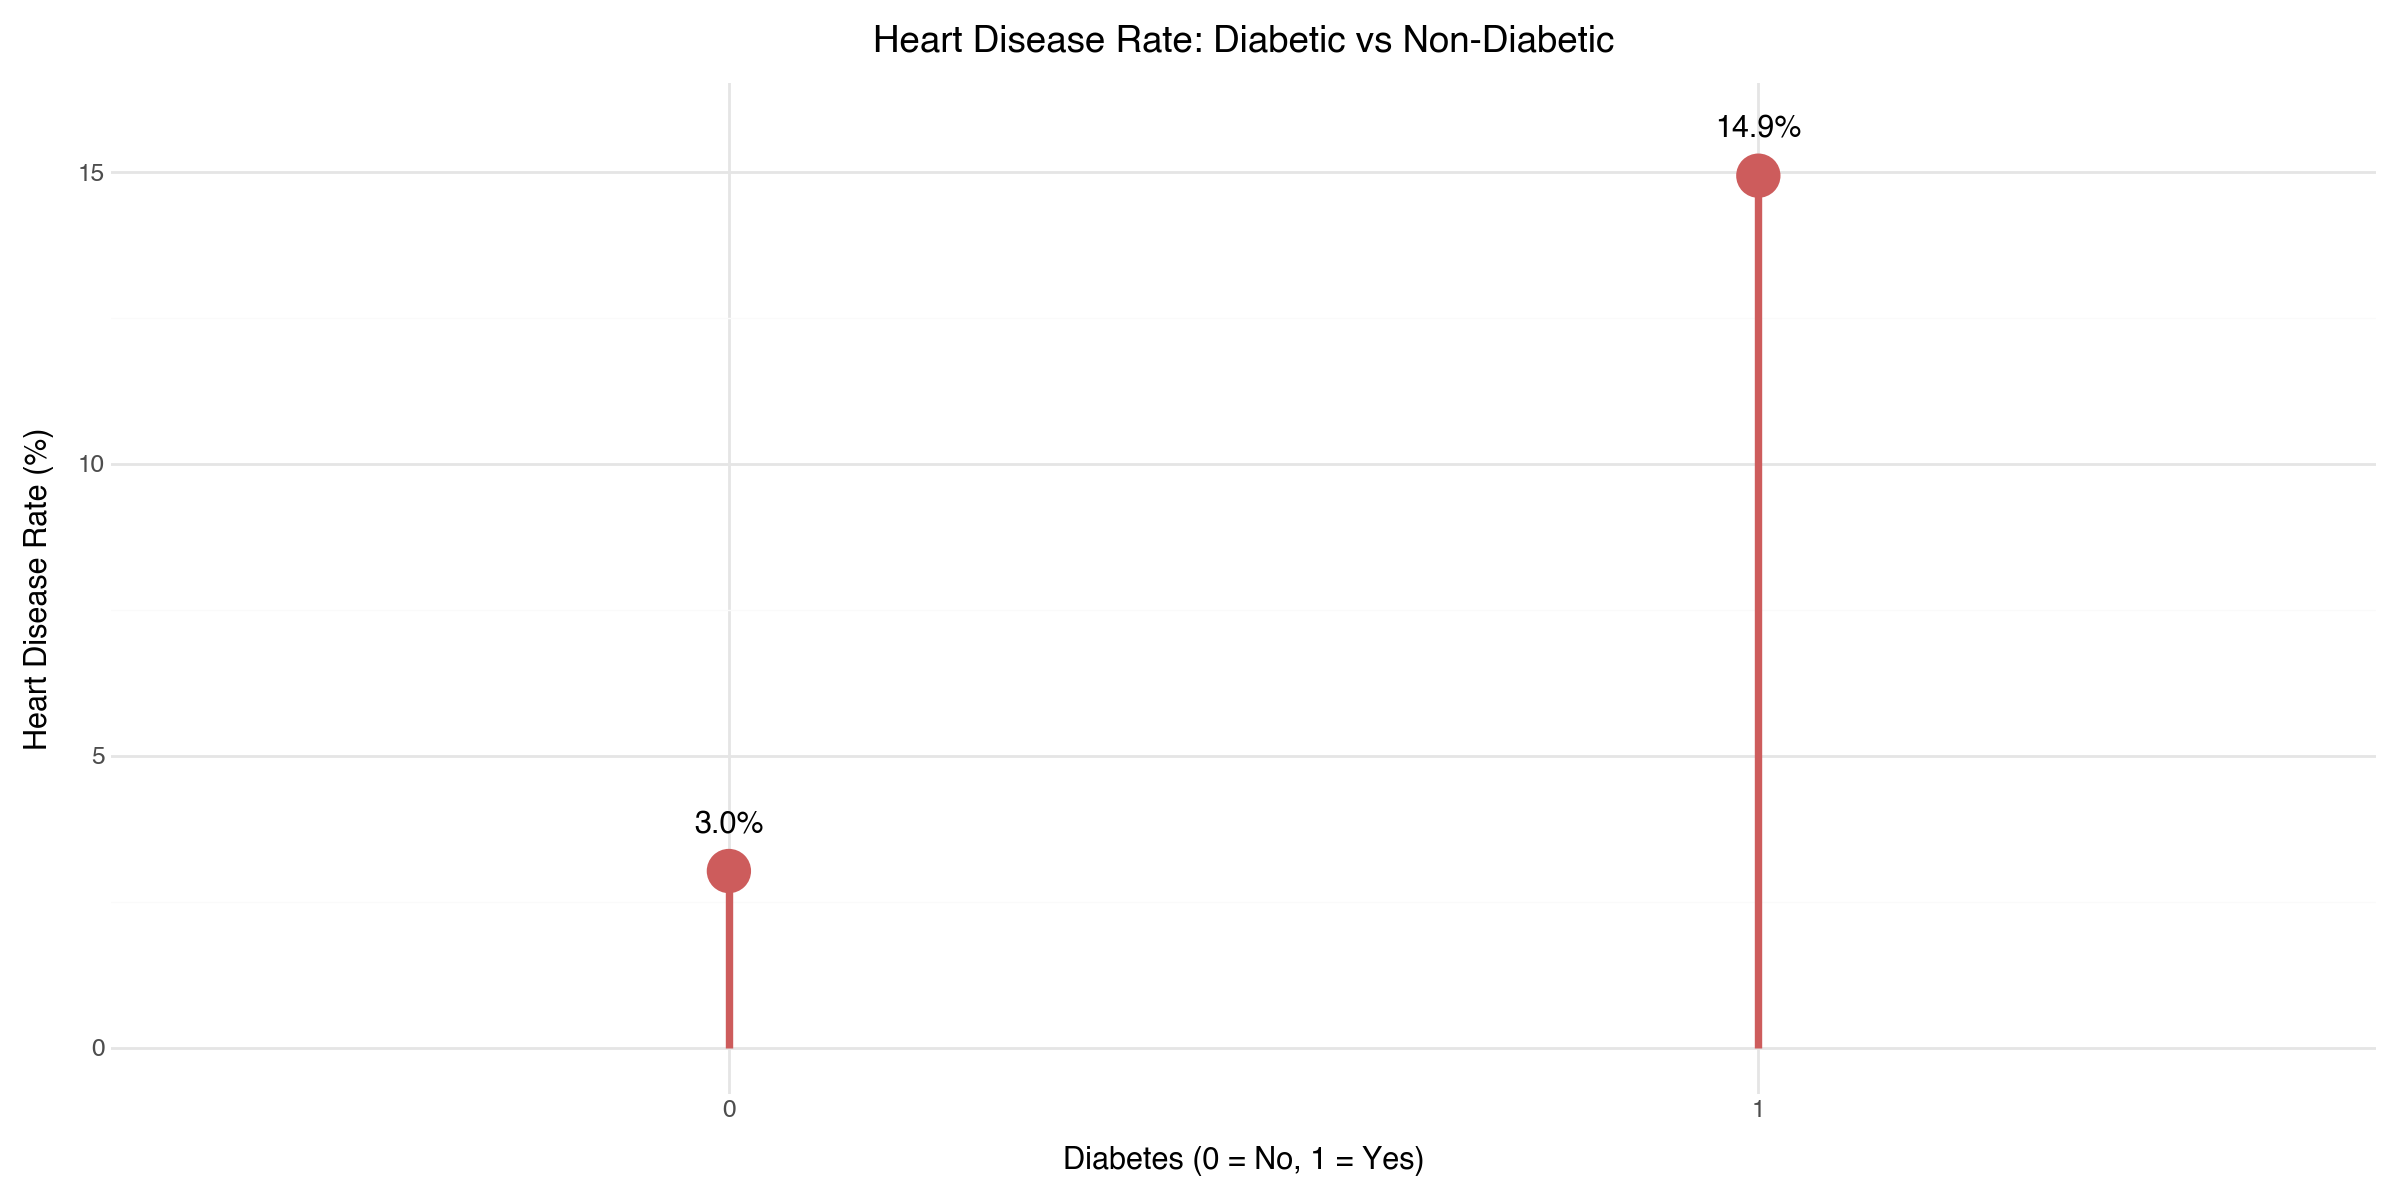

In [61]:


heartdx_data['label'] = heartdx_data['heart_disease'].round(1).astype(str) + '%'

(
    ggplot(heartdx_data, aes(x='factor(diabetes)', y='heart_disease'))
    + geom_segment(
        aes(x='factor(diabetes)', xend='factor(diabetes)', y=0, yend='heart_disease'),
        color='indianred', size=1.5
    )
    + geom_point(size=8, color='indianred')
    + geom_text(aes(label='label'), nudge_y=0.8)   
    + labs(
        title='Heart Disease Rate: Diabetic vs Non-Diabetic',
        x='Diabetes (0 = No, 1 = Yes)',
        y='Heart Disease Rate (%)'
    )
    + theme_minimal()
    + theme(figure_size =(12, 6))
)

##### Interpretation
Heart disease appears to be associated with diabetes. Approximately 14.94% of diabetic patients have heart disease, 
compared to only 3.03% of non-diabetic patients. This suggests that heart disease is considerably more prevalent among patients 
diagnosed with diabetes.

#### Does smoking status influence diabetes prevalence?

In [30]:
cleaned_data.groupby(['smoking_history', 'diabetes']).size()/cleaned_data.groupby('smoking_history').size()*100

smoking_history  diabetes
No Info          0           95.606167
                 1            4.393833
current          0           89.692291
                 1           10.307709
ever             0           88.194097
                 1           11.805903
former           0           82.901387
                 1           17.098613
never            0           90.298855
                 1            9.701145
not current      0           89.162871
                 1           10.837129
dtype: float64

In [31]:
cleaned_data2 = cleaned_data.copy()

In [32]:
smoking_diabetes = (
    cleaned_data2
    .groupby(['smoking_history', 'diabetes'])
    .size()
    .reset_index(name='count')
)

In [33]:
smoking_diabetes['total'] = smoking_diabetes.groupby(
    'smoking_history')['count'].transform('sum')
smoking_diabetes['percentage'] =( 
        smoking_diabetes['count']/smoking_diabetes['total']*100
).round(1)

In [34]:
smoking_diabetes['diabetes'] = smoking_diabetes['diabetes'].map(
    {0: 'No Diabetes', 1: 'Diabetic'}
)    

In [35]:
smokers_data = (
    cleaned_data
    .groupby('smoking_history', as_index=False)['diabetes']
    .mean() * 100
)

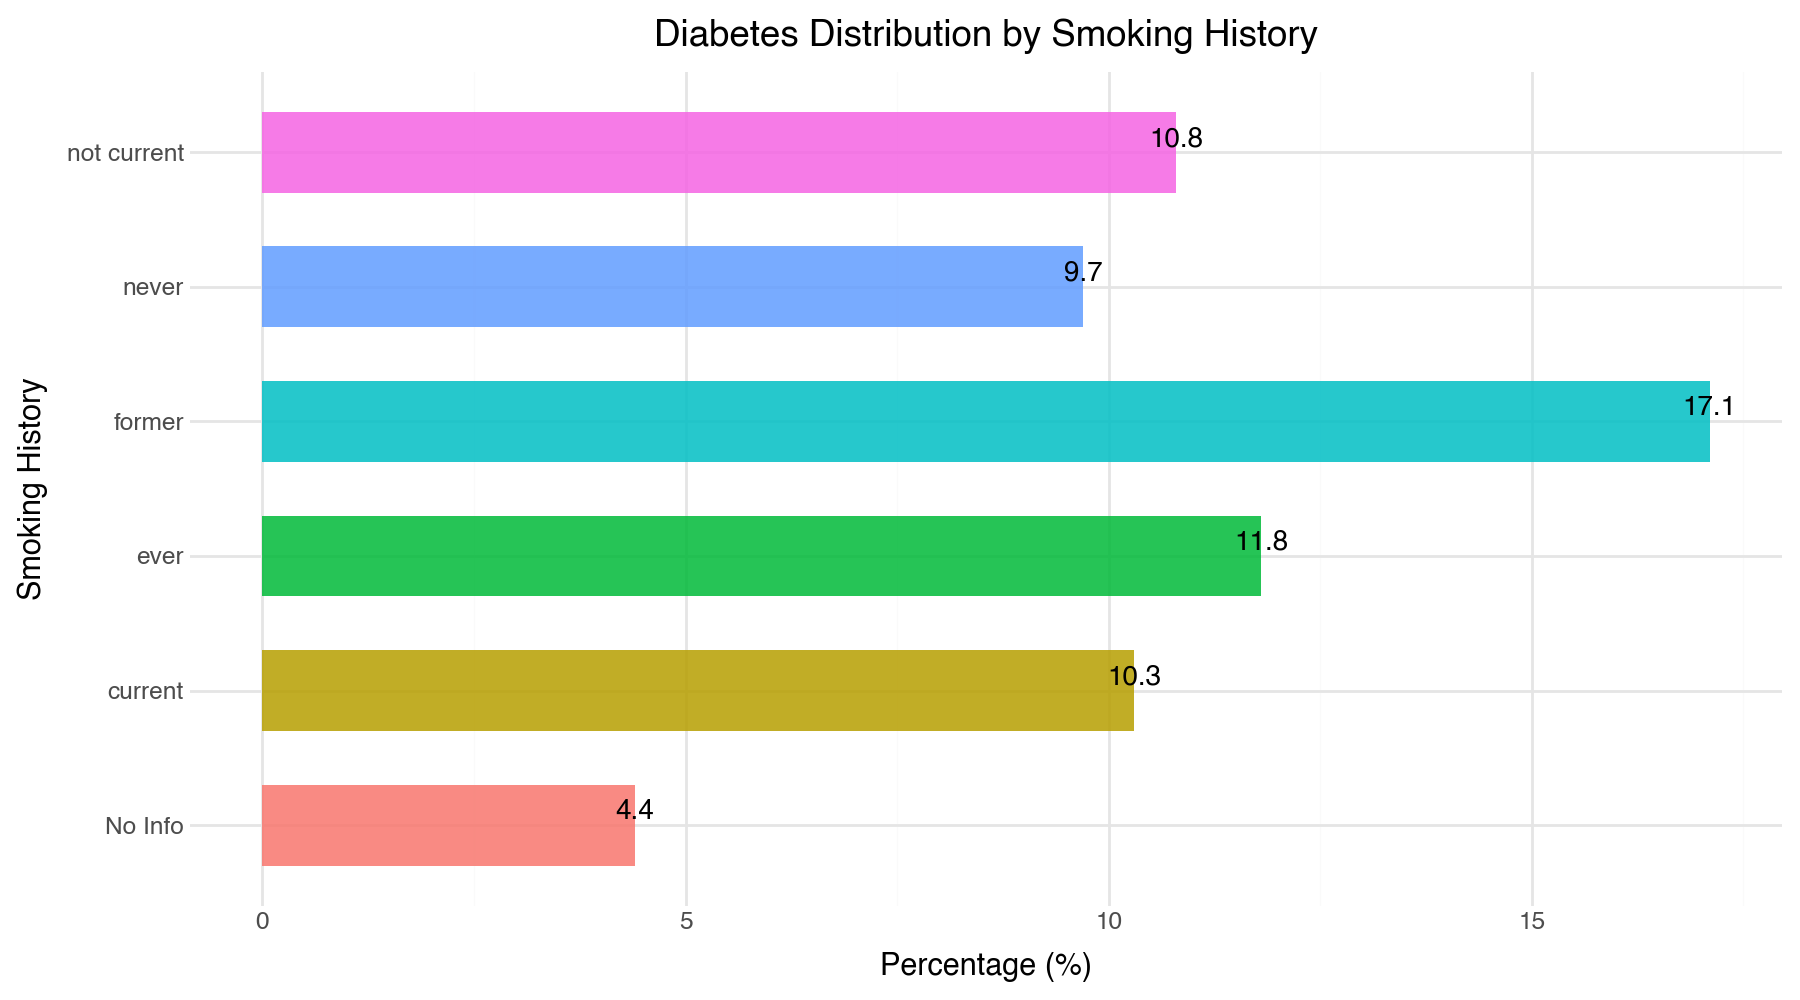

In [36]:
from plotnine import *

(
    ggplot(smoking_diabetes[smoking_diabetes['diabetes'] == 'Diabetic'],
           aes(x='smoking_history', y='percentage', fill='smoking_history'))
    + geom_col(alpha=0.85, width=0.6)
    + geom_text(aes(label='percentage'), va='bottom', size=10)
    + coord_flip()
    + theme_minimal()
    + theme(
        figure_size=(9, 5),
        legend_position='none'
    )
    + labs(
        title='Diabetes Distribution by Smoking History',
        x='Smoking History',
        y='Percentage (%)'
    )
)

#### Interpretation
Former smokers show the highest diabetes prevalence (17.1%), suggesting that past smoking history is a stronger 
risk marker than current smoking status. People who never smoked have the lowest reliable rate (9.7%). The "No Info" group should be 
treated with caution as it likely reflects missing data rather than a true low-risk group.

#### How does BMI differ between diabetic & non-diabetic patients?

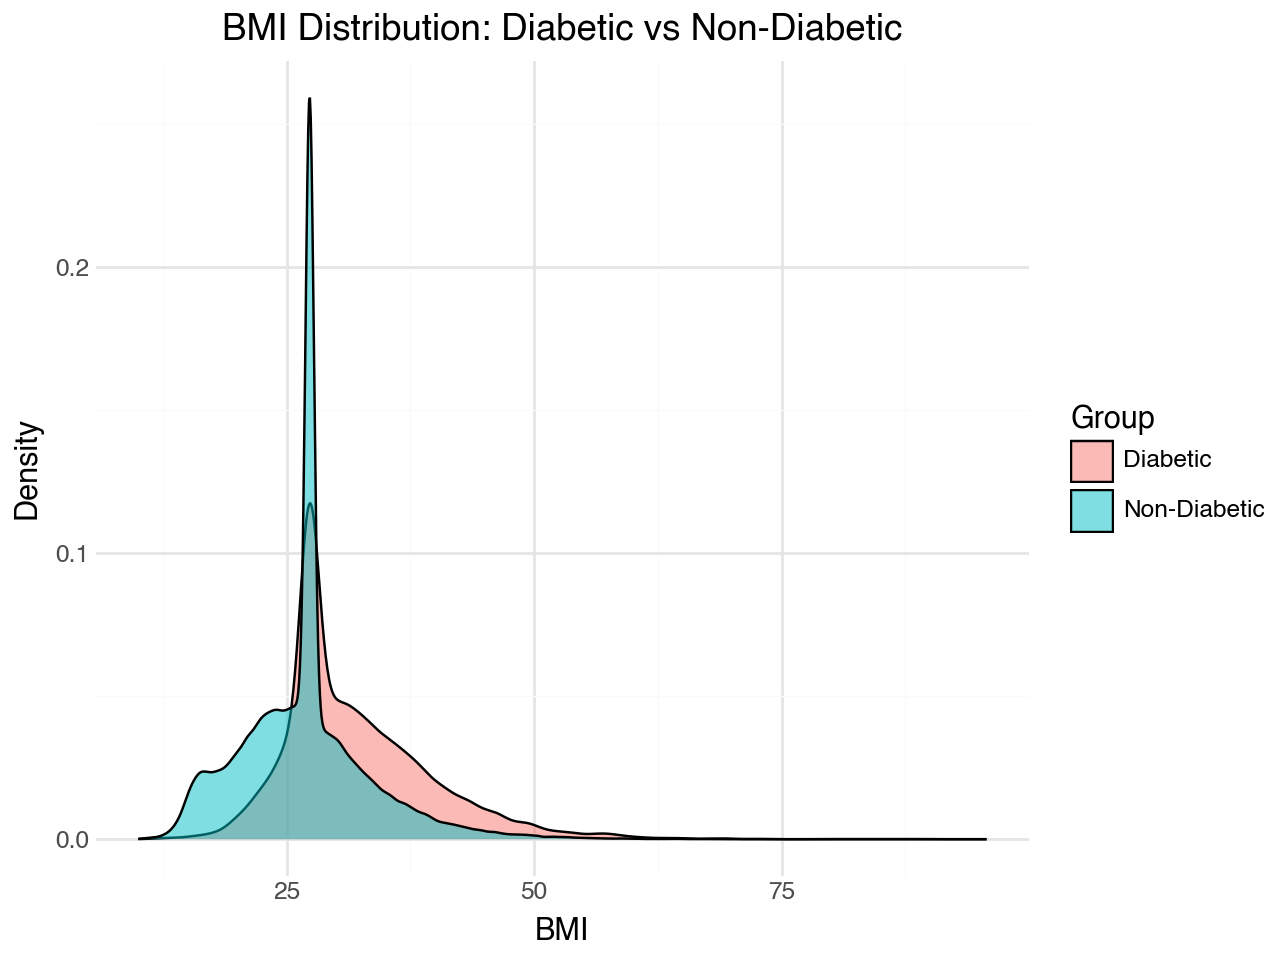

In [37]:
from plotnine import *
import pandas as pd

diabetic = cleaned_data[cleaned_data['diabetes'] == 1]['bmi']
non_diabetic = cleaned_data[cleaned_data['diabetes'] == 0]['bmi']

# Reshape for plotnine
bmi_df = pd.DataFrame({
    'bmi': pd.concat([diabetic, non_diabetic]),
    'group': ['Diabetic'] * len(diabetic) + ['Non-Diabetic'] * len(non_diabetic)
})

# Density plot
(
    ggplot(bmi_df, aes(x='bmi', fill='group'))
    + geom_density(alpha=0.5)
    + labs(
        title='BMI Distribution: Diabetic vs Non-Diabetic',
        x='BMI', y='Density', fill='Group'
    )
    + theme_minimal()
)

##### Interpretation
Yes, BMI does differ between the two groups. While both peak around BMI 27–28, diabetic patients show a broader 
distribution with a notably heavier right tail, indicating a higher prevalence of obesity (BMI > 35) in the diabetic group. 
Non-diabetic patients are more concentrated in the healthy-to-overweight range, suggesting that elevated BMI is a meaningful risk factor for diabetes in this dataset.


#### How does HbA1c level differ between diabetic & non-diabetic patients?


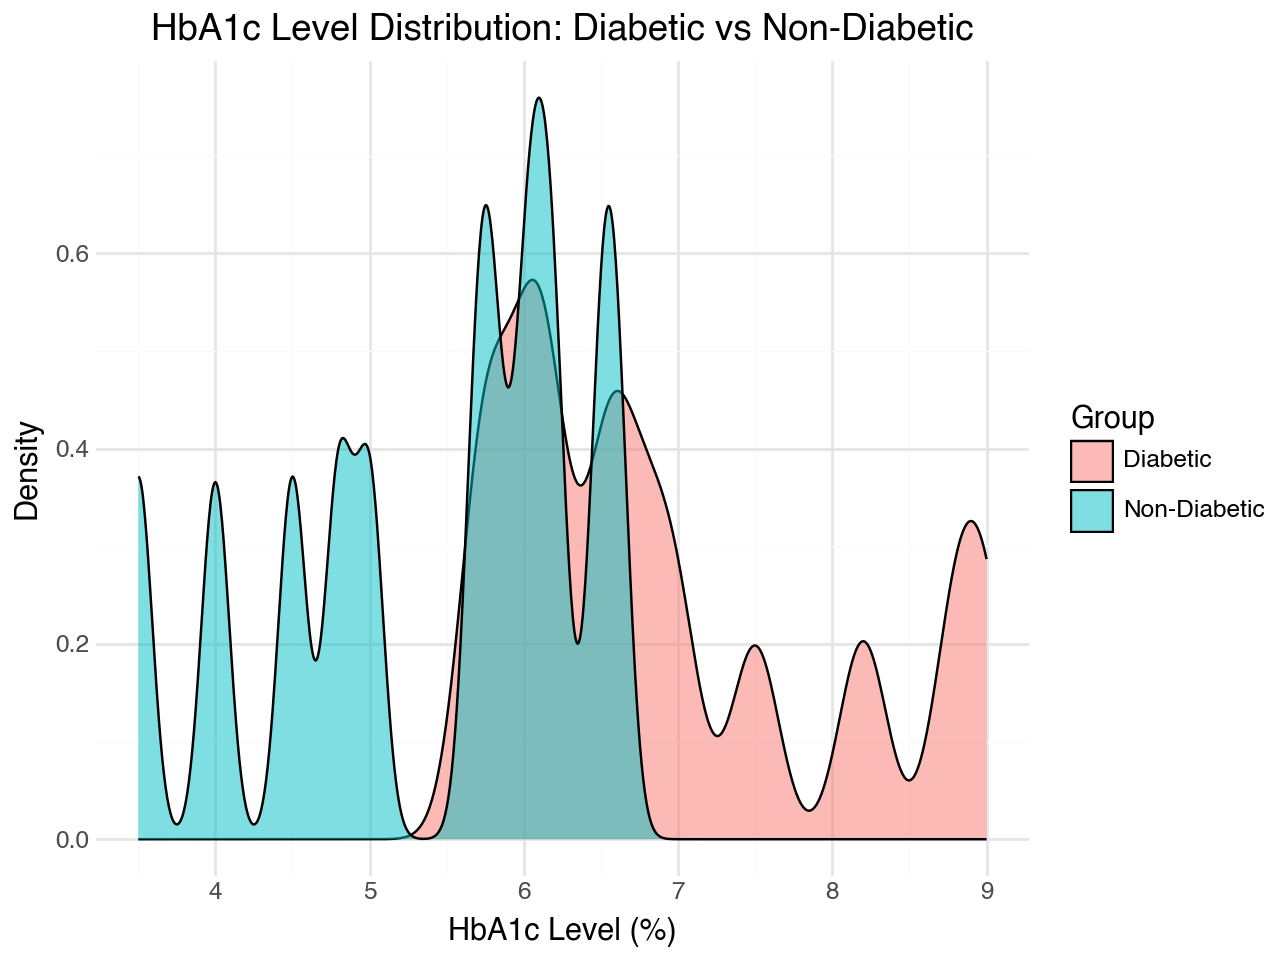

In [38]:
hba1c_df = pd.DataFrame({
    'HbA1c_level': pd.concat([
        cleaned_data[cleaned_data['diabetes'] == 1]['HbA1c_level'],
        cleaned_data[cleaned_data['diabetes'] == 0]['HbA1c_level']
    ]),
    'group': (
        ['Diabetic'] * len(cleaned_data[cleaned_data['diabetes'] == 1]) +
        ['Non-Diabetic'] * len(cleaned_data[cleaned_data['diabetes'] == 0])
    )
})

(
    ggplot(hba1c_df, aes(x='HbA1c_level', fill='group'))
    + geom_density(alpha=0.5)
    + labs(
        title='HbA1c Level Distribution: Diabetic vs Non-Diabetic',
        x='HbA1c Level (%)', y='Density', fill='Group'
    )
    + theme_minimal()
)

##### Interpretation
HbA1c levels show the clearest separation of any variable between diabetic and non-diabetic patients. 
Non-diabetic patients are concentrated below 6.5%, while diabetic patients cluster between 6.5–9.0% — directly mirroring the clinical 
diagnostic threshold of 6.5%. The jagged/multimodal appearance is due to HbA1c being recorded in discrete intervals in this dataset 
rather than as a continuous

#### Does blood glucose level differ between diabetic & non-diabetic patients?


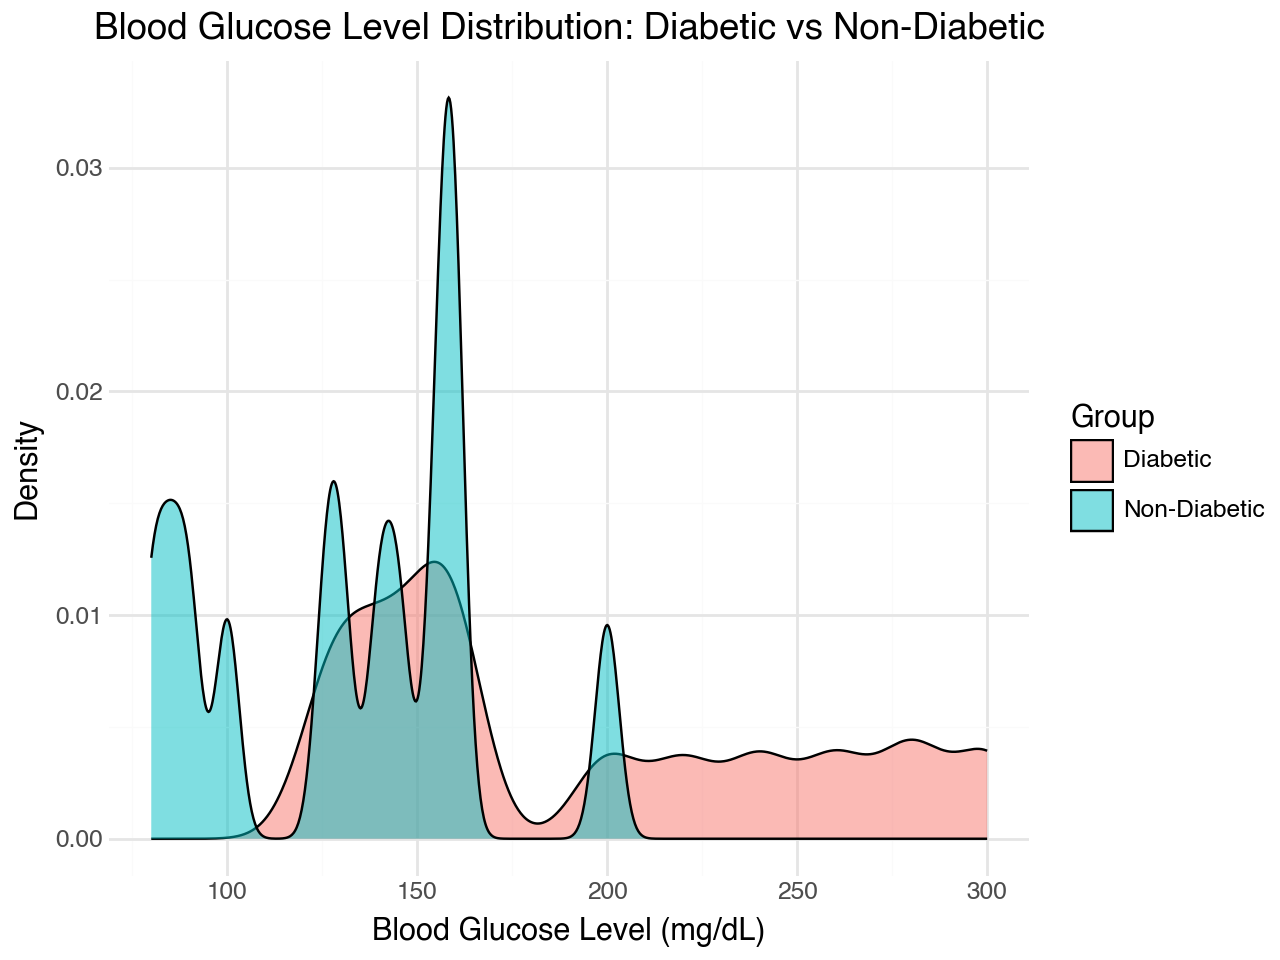

In [39]:

glucose_df = pd.DataFrame({
    'blood_glucose_level': pd.concat([
        cleaned_data[cleaned_data['diabetes'] == 1]['blood_glucose_level'],
        cleaned_data[cleaned_data['diabetes'] == 0]['blood_glucose_level']
    ]),
    'group': (
        ['Diabetic'] * len(cleaned_data[cleaned_data['diabetes'] == 1]) +
        ['Non-Diabetic'] * len(cleaned_data[cleaned_data['diabetes'] == 0])
    )
})

(
    ggplot(glucose_df, aes(x='blood_glucose_level', fill='group'))
    + geom_density(alpha=0.5)
    + labs(
        title='Blood Glucose Level Distribution: Diabetic vs Non-Diabetic',
        x='Blood Glucose Level (mg/dL)', y='Density', fill='Group'
    )
    + theme_minimal()
)

##### Interpretation
Blood glucose levels differ significantly between diabetic and non-diabetic patients. Non-diabetic patients cluster 
predominantly below 200 mg/dL, while diabetic patients show a wider, flatter distribution extending well beyond 200 mg/dL. Values above 
200 mg/dL are almost exclusively found in the diabetic group, consistent with clinical diagnostic thresholds. The multimodal spikes reflect
discrete recording of glucose values in the dataset rather than a true biological pattern.

#### Which factors show the strongest relationship with diabetes?

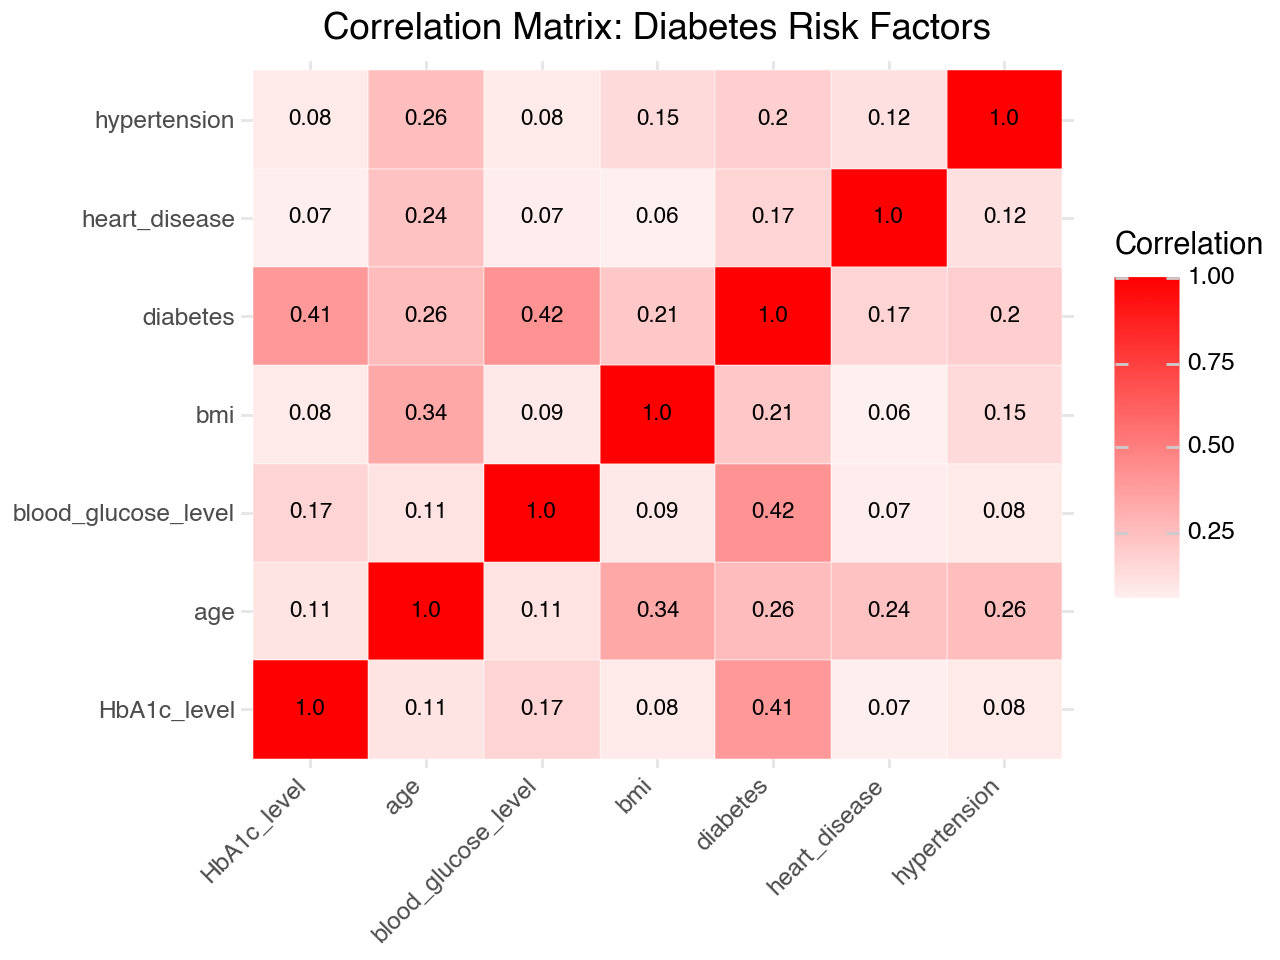

In [40]:
from plotnine import *
import pandas as pd

# Select only numeric columns
numeric_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level', 
                'hypertension', 'heart_disease', 'diabetes']

corr_matrix = cleaned_data[numeric_cols].corr()

# Convert to long format for plotnine
corr_long = corr_matrix.reset_index().melt(id_vars='index')
corr_long.columns = ['var1', 'var2', 'correlation']

# Add correlation labels for display
corr_long['label'] = corr_long['correlation'].round(2).astype(str)

(
    ggplot(corr_long, aes(x='var1', y='var2', fill='correlation'))
    + geom_tile(color='white')
    + geom_text(aes(label='label'), size=8)
    + scale_fill_gradient2(low='steelblue', mid='white', high='red', midpoint=0)
    + labs(
        title='Correlation Matrix: Diabetes Risk Factors',
        x='', y='', fill='Correlation'
    )
    + theme_minimal()
    + theme(axis_text_x=element_text(angle=45, hjust=1))
)

##### Interpretation
HbA1c level and blood glucose level are jointly the strongest predictors of diabetes (both at 0.42), 
followed by age (0.26), BMI (0.21), hypertension (0.20), and heart disease (0.17).

#### What combinations of risk factors charactrize diabetic patients? 

In [41]:

# Step 1: Create risk categories
combo_data = cleaned_data.copy()

combo_data['age_group'] = pd.cut(combo_data['age'], 
                                  bins=[0, 40, 60, 100], 
                                  labels=['Young (<40)', 'Middle (40-60)', 'Older (60+)'])

combo_data['bmi_group'] = pd.cut(combo_data['bmi'],
                                  bins=[0, 25, 30, 100],
                                  labels=['Normal (<25)', 'Overweight (25-30)', 'Obese (30+)'])

combo_data['hba1c_group'] = pd.cut(combo_data['HbA1c_level'],
                                    bins=[0, 5.7, 6.5, 100],
                                    labels=['Normal (<5.7)', 'Prediabetic (5.7-6.5)', 'Diabetic (6.5+)'])

combo_data['glucose_group'] = pd.cut(combo_data['blood_glucose_level'],
                                      bins=[0, 140, 200, 500],
                                      labels=['Normal (<140)', 'Elevated (140-200)', 'High (200+)'])

# Step 2: Group and calculate diabetes rate per combination
combo_summary = (combo_data
    .groupby(['age_group', 'bmi_group', 'hba1c_group'])['diabetes']
    .agg(['mean', 'count'])
    .reset_index()
    .rename(columns={'mean': 'diabetes_rate', 'count': 'n_patients'})
)

combo_summary['diabetes_rate_pct'] = (combo_summary['diabetes_rate'] * 100).round(1)

# Step 3: Filter for meaningful combos (at least 100 patients)
combo_summary = combo_summary[combo_summary['n_patients'] >= 100].sort_values('diabetes_rate_pct', ascending=False)

print(combo_summary.head(10))

         age_group           bmi_group            hba1c_group  diabetes_rate  \
26     Older (60+)         Obese (30+)        Diabetic (6.5+)       0.772161   
17  Middle (40-60)         Obese (30+)        Diabetic (6.5+)       0.589664   
23     Older (60+)  Overweight (25-30)        Diabetic (6.5+)       0.576190   
20     Older (60+)        Normal (<25)        Diabetic (6.5+)       0.483384   
14  Middle (40-60)  Overweight (25-30)        Diabetic (6.5+)       0.334130   
25     Older (60+)         Obese (30+)  Prediabetic (5.7-6.5)       0.296690   
8      Young (<40)         Obese (30+)        Diabetic (6.5+)       0.253641   
11  Middle (40-60)        Normal (<25)        Diabetic (6.5+)       0.218284   
16  Middle (40-60)         Obese (30+)  Prediabetic (5.7-6.5)       0.174607   
22     Older (60+)  Overweight (25-30)  Prediabetic (5.7-6.5)       0.166597   

    n_patients  diabetes_rate_pct  
26        1444               77.2  
17        1606               59.0  
23        1

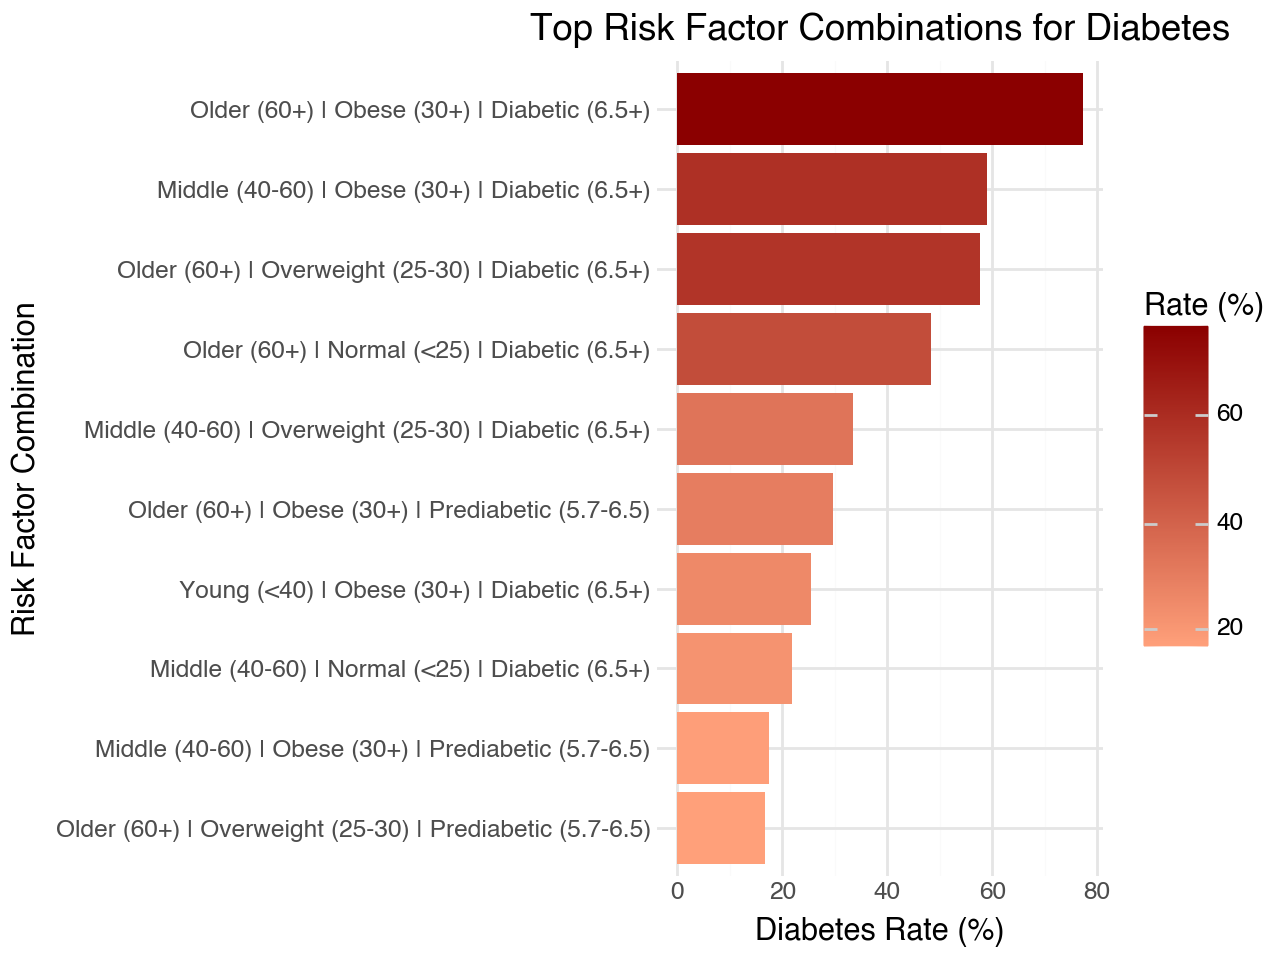

In [42]:

top_combos = combo_summary.head(10).copy()
top_combos['combo_label'] = (top_combos['age_group'].astype(str) + ' | ' + 
                              top_combos['bmi_group'].astype(str) + ' | ' + 
                              top_combos['hba1c_group'].astype(str))

(
    ggplot(top_combos, aes(x='reorder(combo_label, diabetes_rate_pct)', 
                           y='diabetes_rate_pct',
                           fill='diabetes_rate_pct'))
    + geom_col()
    + coord_flip()
    + scale_fill_gradient(low='lightsalmon', high='darkred')
    + labs(
        title='Top Risk Factor Combinations for Diabetes',
        x='Risk Factor Combination',
        y='Diabetes Rate (%)',
        fill='Rate (%)'
    )
    + theme_minimal()
)

##### Interpretation
The most striking observation is that HbA1c level is the strongest driver of diabetes risk; every high-risk combination features a diabetic HbA1c reading of 6.5 and above, regardless of the other factors. Older individuals (60+) who are obese and have a diabetic HbA1c level show the highest diabetes rate at approximately 75%, followed closely by middle-aged (40-60) obese individuals with similarly elevated HbA1c. Notably, even older adults with normal BMI but diabetic HbA1c levels still show around 50% diabetes rates, suggesting that age and blood sugar levels alone are sufficient to confer significant risk. Combinations featuring prediabetic HbA1c levels (5.7-6.5) consistently appear at the bottom of the chart with lower rates, further reinforcing the dominance of HbA1c as a predictor. Overall, the chart suggests that while age amplifies risk and obesity compounds it, HbA1c level remains the most critical factor, and these three variables are likely to rank among the most important features in the predictive model.

Diabetes formula = older age + higher bmi + high blood sugar + high HbA1c levels

### DATA PRE-PROCESSING

In [43]:
# Encoding; this is to convert categorical data into numerical form 

cleaned_data_cpy2 = pd.get_dummies(cleaned_data_cpy, 
                              columns = ['gender', 'smoking_history'],
                              drop_first =True,
                              dtype = int)

In [44]:
cleaned_data_cpy2.head()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_Male,gender_Other,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,80.0,0,1,25.19,6.6,140,0,0,0,0,0,0,1,0
1,54.0,0,0,27.32,6.6,80,0,0,0,0,0,0,0,0
2,28.0,0,0,27.32,5.7,158,0,1,0,0,0,0,1,0
3,36.0,0,0,23.45,5.0,155,0,0,0,1,0,0,0,0
4,76.0,1,1,20.14,4.8,155,0,1,0,1,0,0,0,0


In [45]:
# Split data into train & test
from sklearn.model_selection import train_test_split

X = cleaned_data_cpy2[['age', 'bmi', 'HbA1c_level', 'blood_glucose_level', 
                   'hypertension', 'heart_disease','gender_Male', 'gender_Other',
                   'smoking_history_current', 'smoking_history_ever', 
                   'smoking_history_former', 'smoking_history_never', 
                   'smoking_history_not current']]
y = cleaned_data_cpy2['diabetes']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size =0.2, random_state =42, stratify =y)

In [46]:
#Standardization
#Since the data are on different scale, this solves that problem. I'd only scale the training data to prevent data leakage

In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


### DATA MODELLING

#### Logistic Regression


In [48]:

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import *


model =LogisticRegression(class_weight = 'balanced', random_state =42)
model.fit(X_train_scaled, y_train)

# Predictions
y_pred = model.predict(X_test_scaled)

# ROC_AUC
lr_prob = model.predict_proba(X_test_scaled)[:,1]
lr_auc = roc_auc_score(y_test, lr_prob)

#### LR Evaluation


In [49]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [50]:
# Classification report
print('Logistic regression classification report')
print(classification_report(y_test, y_pred))

Logistic regression classification report
              precision    recall  f1-score   support

           0       0.99      0.88      0.93     17534
           1       0.43      0.88      0.57      1696

    accuracy                           0.88     19230
   macro avg       0.71      0.88      0.75     19230
weighted avg       0.94      0.88      0.90     19230



##### Interpretation
The model is excellent at finding diabetic patients (recall 0.88) and ranking them correctly (ROC-AUC ~0.96), but raises many false alarms (precision 0.43),an acceptable trade-off for medical screening.

#### Random Forest

#### Grid Search; this was done inorder to figure out the best n-estimator to optimize my Random Forest

In [51]:
# Define parameters
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid ={
     'n_estimators': [100, 200, 300],
     'max_depth': [5, 10, 15, None],
     'min_samples_split':[2, 5, 10]
}

# Set up grid search
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(
                  class_weight='balanced', 
                  random_state=42),
    param_grid=param_grid,
    cv=5,              
    scoring='recall',  
    n_jobs=-1,         
    verbose=2         
)


In [52]:
# Fit on training data  

grid_search.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
[CV] END .max_depth=5, min_samples_split=2, n_estimators=100; total time=   9.6s
[CV] END .max_depth=5, min_samples_split=2, n_estimators=200; total time=  18.8s
[CV] END .max_depth=5, min_samples_split=2, n_estimators=200; total time=  18.9s
[CV] END .max_depth=5, min_samples_split=2, n_estimators=300; total time=  24.3s
[CV] END .max_depth=5, min_samples_split=5, n_estimators=100; total time=   6.3s
[CV] END .max_depth=5, min_samples_split=5, n_estimators=200; total time=  21.8s
[CV] END .max_depth=5, min_samples_split=5, n_estimators=200; total time=  15.8s


/Users/deca/Downloads/summerschool/venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.


[CV] END .max_depth=5, min_samples_split=2, n_estimators=100; total time=   9.7s
[CV] END .max_depth=5, min_samples_split=2, n_estimators=200; total time=  19.0s
[CV] END .max_depth=5, min_samples_split=2, n_estimators=300; total time=  31.2s
[CV] END .max_depth=5, min_samples_split=5, n_estimators=100; total time=  11.0s
[CV] END .max_depth=5, min_samples_split=5, n_estimators=100; total time=   7.9s
[CV] END .max_depth=5, min_samples_split=5, n_estimators=200; total time=  21.9s
[CV] END .max_depth=5, min_samples_split=5, n_estimators=300; total time=  28.8s
[CV] END .max_depth=5, min_samples_split=2, n_estimators=100; total time=   7.3s
[CV] END .max_depth=5, min_samples_split=2, n_estimators=100; total time=   8.2s
[CV] END .max_depth=5, min_samples_split=2, n_estimators=200; total time=  15.7s
[CV] END .max_depth=5, min_samples_split=2, n_estimators=300; total time=  31.0s
[CV] END .max_depth=5, min_samples_split=5, n_estimators=100; total time=  10.7s
[CV] END .max_depth=5, min_s

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;-

In [53]:
best_rf = grid_search.best_params_
print("Best Parameters:", best_rf)

Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 300}


In [54]:

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train_scaled, y_train)



,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

#### Prediction

In [55]:

rf_pred = rf_model.predict(X_test_scaled)

# ROC_AUC
rf_prob = rf_model.predict_proba(X_test_scaled)[:, 1]
rf_auc = roc_auc_score(y_test, rf_prob)

#### RF Evaluation

In [56]:

# classification report
print('Random Forest classification report')
print(classification_report(y_test, rf_pred))

Random Forest classification report
              precision    recall  f1-score   support

           0       0.99      0.90      0.94     17534
           1       0.46      0.90      0.61      1696

    accuracy                           0.90     19230
   macro avg       0.72      0.90      0.77     19230
weighted avg       0.94      0.90      0.91     19230



##### Interpretation
The Random Forest model achieved an overall accuracy of 90%. For diabetic patients (Class 1), the model attained a recall of 90%, indicating that it successfully identified 90% of individuals with diabetes. Although the precision for the diabetic class was 46%, suggesting the presence of false positives, the high recall makes the model suitable for screening purposes where minimizing missed diabetic cases is a priority. The model therefore demonstrates strong potential for early diabetes detection.

#### Feature Importance Plot

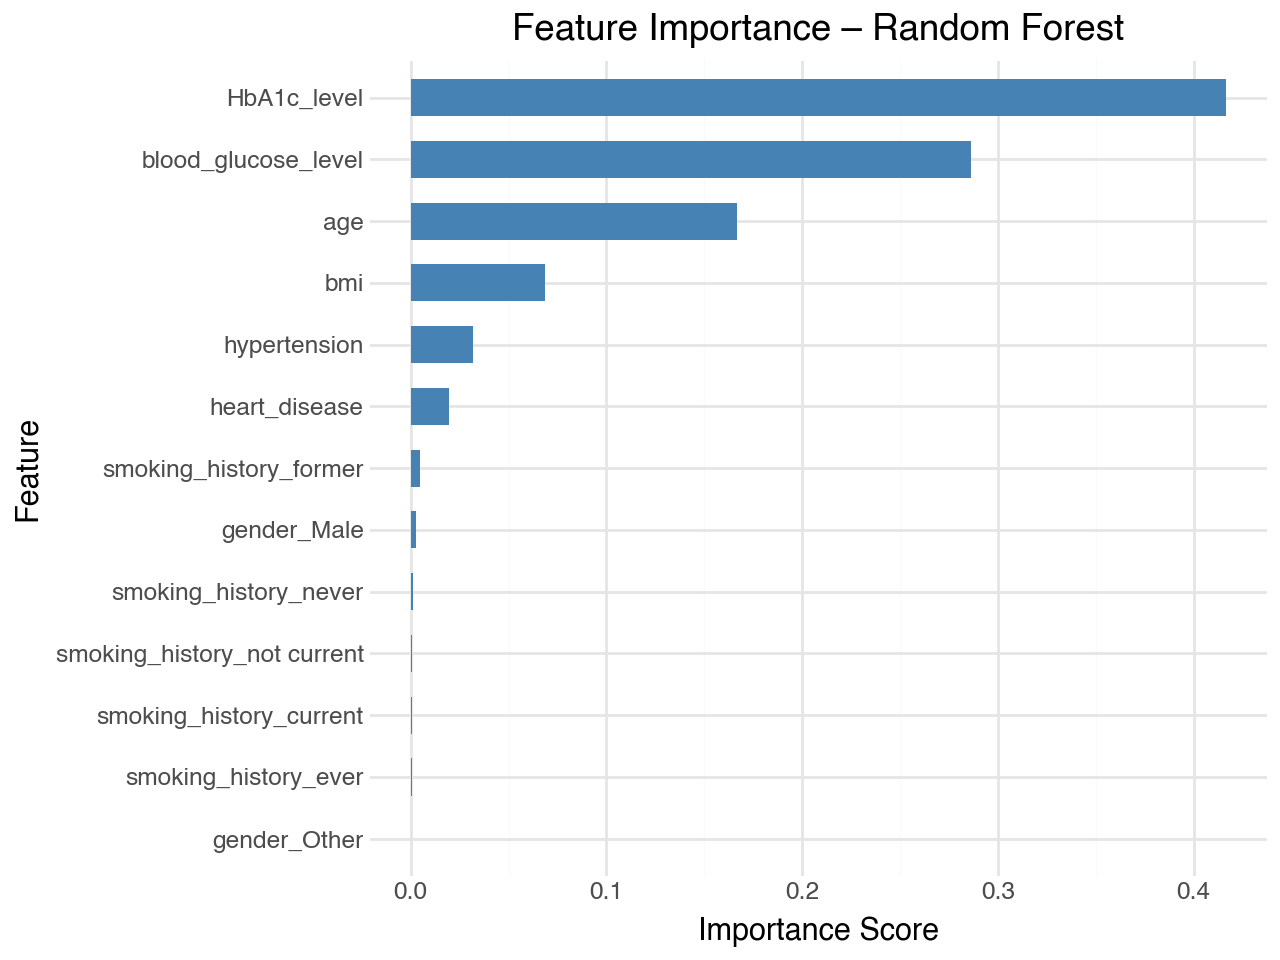

In [62]:
# Feature Importance
feat_imp = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False).reset_index()
feat_imp.columns = ['feature', 'importance']

(
    ggplot(feat_imp, aes(x='reorder(feature, importance)', y='importance'))
    + geom_col(fill='steelblue', width=0.6)
    + coord_flip()
    + theme_minimal()
    + labs(
        title='Feature Importance – Random Forest',
        x='Feature',
        y='Importance Score'
    )
)

In [57]:
# Confusion matrix

rf_cm = confusion_matrix(y_test, rf_pred)
print('Confusion matrix')
print(rf_cm)

Confusion matrix
[[15724  1810]
 [  166  1530]]


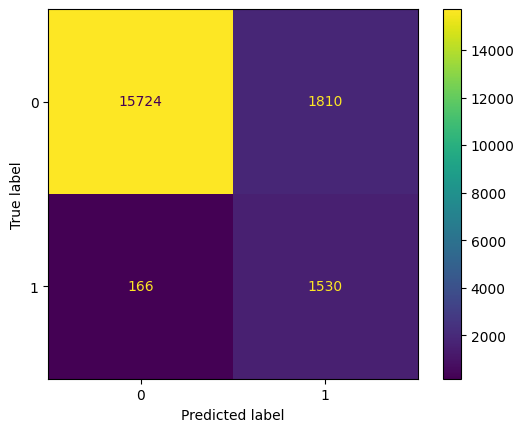

In [58]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, rf_pred)
plt.show()

##### Interpretation
The confusion matrix shows that the model performs well overall but has a tendency to over-predict the positive class. It correctly classifies a large number of negative cases (15,724 true negatives) and also successfully identifies most positive cases (1,530 true positives), indicating strong ability to detect both classes. However, it also produces a considerable number of false positives (1,810), meaning it sometimes incorrectly labels negative cases as positive, while missing a smaller number of actual positives (166 false negatives). This results in a model with high recall but relatively lower precision, meaning it is good at finding positives but less reliable when it predicts a positive outcome.

In [63]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(rf_model, X_train_scaled, y_train, cv=5, scoring='recall')

print(f"CV Recall Scores: {cv_scores.round(3)}")
print(f"Mean Recall: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

CV Recall Scores: [0.915 0.914 0.903 0.91  0.9  ]
Mean Recall: 0.908 ± 0.006


##### Interpretation
Cross-validation confirms the model is stable. Recall stays between 90–91.5% across all 5 folds (mean: 90.8%, std: ±0.006), consistent with test performance. This rules out overfitting to a single split.

#### Comparison of both models


In [59]:

comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Diabetic Precision', 'Diabetic Recall',
               'Diabetic F1', 'ROC-AUC'],
    'Logistic Regression': [0.88, 0.43, 0.88, 0.57, lr_auc],
    'Random Forest':       [0.90, 0.46, 0.90, 0.61, rf_auc]
})

print(comparison_df)

               Metric  Logistic Regression  Random Forest
0            Accuracy             0.880000       0.900000
1  Diabetic Precision             0.430000       0.460000
2     Diabetic Recall             0.880000       0.900000
3         Diabetic F1             0.570000       0.610000
4             ROC-AUC             0.960074       0.973863


##### Interpretation

##### What Each Metric Means

- **Accuracy:** Random Forest correctly classifies 90% of all patients vs 88% for Logistic Regression
- **Diabetic Precision (43–46%):** When the model predicts diabetes, it is correct less than half the time — this is low, likely due to class imbalance in the dataset
- **Diabetic Recall (88–90%):** Both models are excellent at catching actual diabetes cases very important in a medical context where missing a case is costly
- **F1 Score:** Random Forest (0.61) balances precision and recall better than Logistic Regression (0.57)
- **ROC-AUC:** Both scores are excellent (>0.95), with Random Forest (0.974) 
  edging ahead — confirming it separates diabetic from non-diabetic patients better

##### Key Insight  
In medical diagnosis, **high Recall matters more than high Precision.**
It is far safer to flag a healthy patient for further testing (false positive) 
than to miss an actual diabetic case (false negative). Both models prioritise this well.

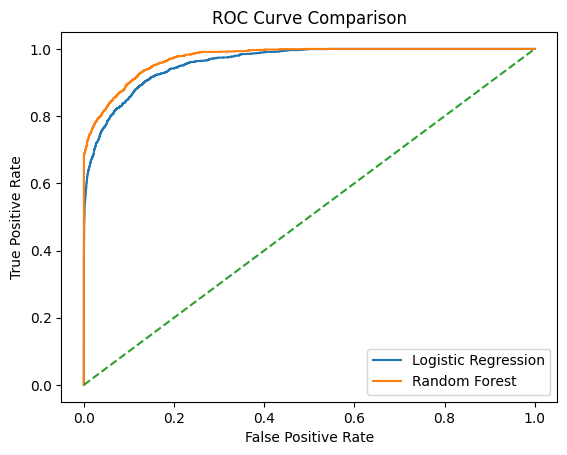

In [60]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)

plt.plot(lr_fpr, lr_tpr, label="Logistic Regression")
plt.plot(rf_fpr, rf_tpr, label="Random Forest")
plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

##### ROC Curve Interpretation

The ROC curve compares the performance of two models —Logistic Regression** and Random Forest — for diabetes prediction.

- The X-axis shows the False Positive Rate (healthy patients wrongly flagged)
- The Y-axis shows the True Positive Rate (actual diabetes cases correctly identified)
- The green dashed diagonal represents a random model (AUC = 0.5) — our baseline

#### Key Findings
- Both models perform significantly better than random guessing
- Random Forest(orange) slightly outperforms Logistic Regression (blue), 
  as its curve hugs the top-left corner more tightly
- Both models achieve an estimated AUC of ~0.85–0.95, which is considered very good
- At a False Positive Rate of ~0.2, both models capture ~90% of true diabetes cases

#### Conclusion
Random Forest is the stronger model for this dataset based on ROC performance.


#### Precision-Recall Curve

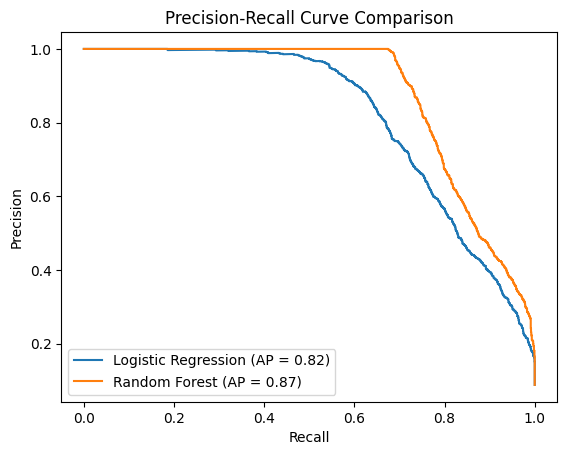

In [64]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Precision-Recall Curve
lr_precision, lr_recall, _ = precision_recall_curve(y_test, lr_prob)
rf_precision, rf_recall, _ = precision_recall_curve(y_test, rf_prob)

lr_ap = average_precision_score(y_test, lr_prob)
rf_ap = average_precision_score(y_test, rf_prob)

plt.plot(lr_recall, lr_precision, label=f"Logistic Regression (AP = {lr_ap:.2f})")
plt.plot(rf_recall, rf_precision, label=f"Random Forest (AP = {rf_ap:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.show()

##### Interpretation

The Precision-Recall curve accounts for class imbalance (91.2% vs 8.8%). Random Forest (AP = 0.87) outperforms Logistic Regression (AP = 0.82), maintaining higher precision across recall thresholds. Both curves confirm the earlier finding: pushing for higher recall to catch more diabetic patients comes at the cost of more false positives;an acceptable trade-off in a medical screening context.

#### Project Summary & Conclusion

**Dataset:** 96,146 patient records (after removing duplicates) with features spanning demographics, lifestyle, and clinical measurements.

---

### Key EDA Findings
- HbA1c level and blood glucose are the strongest predictors of diabetes (r = 0.42 each)
- The 71–80 age group has the highest diabetes prevalence at ~21%
- Former smokers show a higher diabetes rate (17.1%) than current smokers — suggesting cumulative damage
- Heart disease is ~5x more prevalent in diabetic patients (14.9% vs 3%)
- High HbA1c (≥6.5%) alone can drive ~50% diabetes rates, even with normal BMI

---

### Model Performance Summary

| Metric | Logistic Regression | Random Forest |
|---|---|---|
| Accuracy | 88% | 90% |
| Recall (Diabetic) | 88% | 90% |
| ROC-AUC | 0.96 | 0.97 |
| Average Precision | 0.82 | 0.87 |

---

### Recommendation
**Random Forest is the recommended model** for this diabetes prediction task — it outperforms Logistic Regression across every metric and is validated by cross-validation (mean recall: 90.8% ± 0.006).

In a healthcare screening context, high recall matters most: it is far safer to flag a healthy patient for further testing than to miss an actual diabetic case.